In [1]:
DATA_DIR = 'data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Master
products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date']) #
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date']) #
geography = pd.read_csv(DATA_DIR + 'geography.csv')
# Transaction
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date']) #
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date']) #
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date']) #
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date']) #
# Analytical
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date']) #
# Operational
inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date']) #
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')

# Data cleaning & Preprocessing

In [4]:
def quick_check(df, df_name):
    print(f"\n{'='*10} CHECKING TABLE: {df_name} {'='*10}")
    # Overall
    df.info()
    print(df.describe())

    # 1. Duplicates
    print(f"Duplicates: {df.duplicated().sum()} rows")

    # 2. Null values
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("Nulls found:\n", null_counts[null_counts > 0])
    else:
        print("No null values.")

    # 3. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

In [5]:
quick_check(products, 'products')
quick_check(customers, 'customers')
quick_check(promotions, 'promotions')
quick_check(geography, 'geography')
quick_check(orders, 'orders')
quick_check(order_items, 'order_items')
quick_check(payments, 'payments')
quick_check(shipments, 'shipments')
quick_check(returns, 'returns')
quick_check(reviews, 'reviews')
quick_check(sales, 'sales')
quick_check(inventory, 'inventory')
quick_check(web_traffic, 'web_traffic')


========== CHECKING TABLE: products ==========
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   7720.513784   586

- The data seems clean with valid values, only `promotion` and `order_items` have null values.
- Next we'll deal with this and also check for some specific constraints given in the task.

In [6]:
invalid_products = products[products['cogs'] >= products['price']]
len(invalid_products)

0

In [7]:
display(promotions.head())
print('\n', promotions['applicable_category'].unique())

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,NaN,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,NaN,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,NaN,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,NaN,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000



 <StringArray>
[nan, 'Streetwear', 'Outdoor']
Length: 3, dtype: str


In [8]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('Any')

In [9]:
promotions['promo_type'].unique()

<StringArray>
['percentage', 'fixed']
Length: 2, dtype: str

In [10]:
display(order_items.head())
print('\n', order_items['promo_id'].unique())
print('\n', order_items['promo_id_2'].unique())

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN



 <StringArray>
[         nan, 'PROMO-0006', 'PROMO-0001', 'PROMO-0002', 'PROMO-0005',
 'PROMO-0003', 'PROMO-0004', 'PROMO-0007', 'PROMO-0008', 'PROMO-0009',
 'PROMO-0010', 'PROMO-0016', 'PROMO-0011', 'PROMO-0012', 'PROMO-0015',
 'PROMO-0013', 'PROMO-0014', 'PROMO-0017', 'PROMO-0018', 'PROMO-0019',
 'PROMO-0020', 'PROMO-0026', 'PROMO-0021', 'PROMO-0022', 'PROMO-0025',
 'PROMO-0023', 'PROMO-0024', 'PROMO-0027', 'PROMO-0028', 'PROMO-0029',
 'PROMO-0030', 'PROMO-0036', 'PROMO-0031', 'PROMO-0032', 'PROMO-0035',
 'PROMO-0033', 'PROMO-0034', 'PROMO-0037', 'PROMO-0038', 'PROMO-0039',
 'PROMO-0040', 'PROMO-0046', 'PROMO-0041', 'PROMO-0042', 'PROMO-0045',
 'PROMO-0043', 'PROMO-0044', 'PROMO-0047', 'PROMO-0048', 'PROMO-0049',
 'PROMO-0050']
Length: 51, dtype: str

 <StringArray>
[nan, 'PROMO-0015', 'PROMO-0025']
Length: 3, dtype: str


In [11]:
order_items['promo_id'] = order_items['promo_id'].fillna('No_Promo')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('No_Promo')

# Overall EDA

### Bức tranh Toàn cảnh: Xu hướng Doanh thu & Lợi nhuận gộp
Mục tiêu là phác họa tổng thể doanh thu qua thời gian dài để nhận định xu hướng dài hạn.

In [12]:
sales_ts = sales.set_index('Date')
sales_ts.head()

,Revenue,COGS
Date,,
2012-07-04,5123547.94,3982991.19
2012-07-05,2751773.45,2150580.23
2012-07-06,3054029.42,2517632.84
2012-07-07,2667930.94,2108246.62
2012-07-08,2360851.90,1808622.79


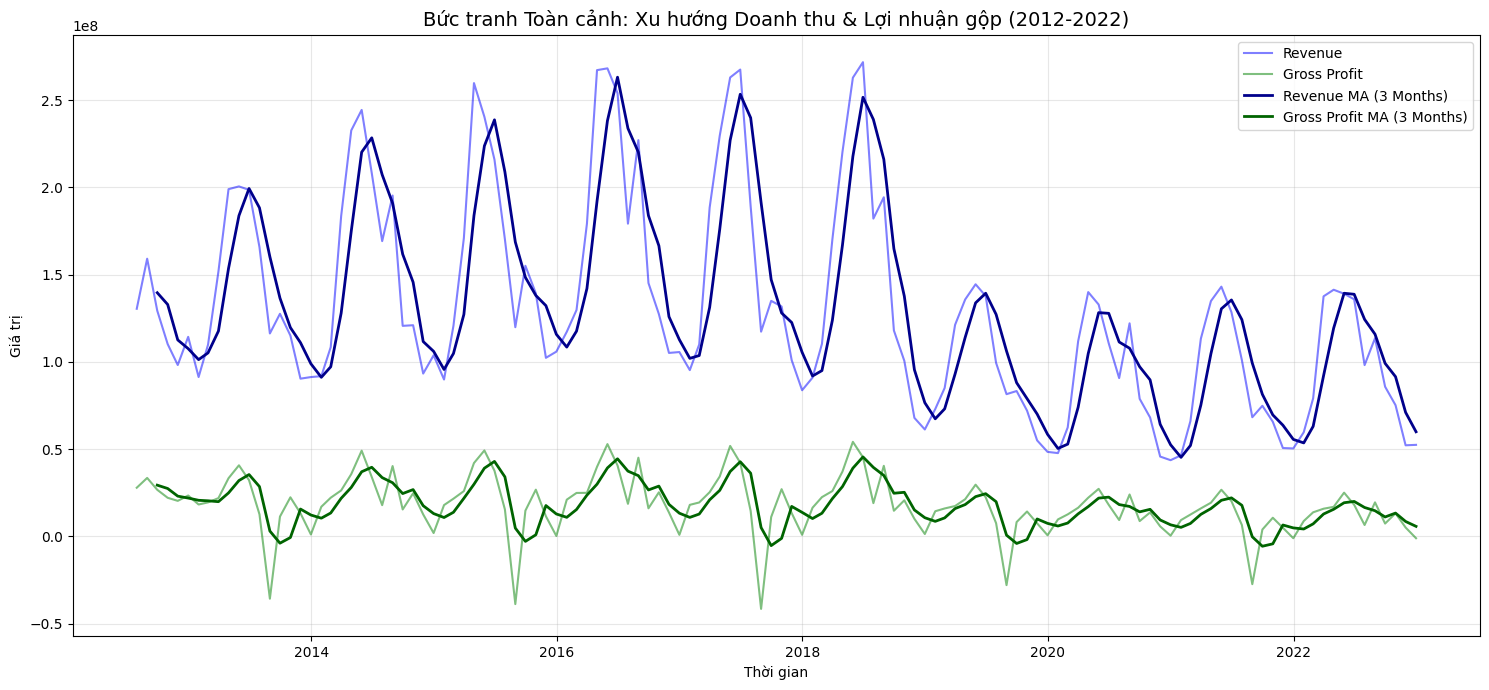

In [13]:
# Tính toán Lợi nhuận gộp (Gross Profit) = Revenue - COGS
sales_ts['Gross_Profit'] = sales_ts['Revenue'] - sales_ts['COGS']
monthly_sales = sales_ts[['Revenue', 'Gross_Profit']].resample('ME').sum()  # Dùng 'ME' hoặc 'M' tùy phiên bản Pandas

# Tính Moving Average 3 tháng để làm mượt đường xu hướng
monthly_sales['Rev_MA_3'] = monthly_sales['Revenue'].rolling(window=3).mean()
monthly_sales['GP_MA_3'] = monthly_sales['Gross_Profit'].rolling(window=3).mean()

plt.figure(figsize=(15, 7))
plt.plot(monthly_sales.index, monthly_sales['Revenue'], label='Revenue', alpha=0.5, color='blue')
plt.plot(monthly_sales.index, monthly_sales['Gross_Profit'], label='Gross Profit', alpha=0.5, color='green')
plt.plot(monthly_sales.index, monthly_sales['Rev_MA_3'], label='Revenue MA (3 Months)', linewidth=2, color='darkblue')
plt.plot(monthly_sales.index, monthly_sales['GP_MA_3'], label='Gross Profit MA (3 Months)', linewidth=2, color='darkgreen')

plt.title('Bức tranh Toàn cảnh: Xu hướng Doanh thu & Lợi nhuận gộp (2012-2022)', fontsize=14)
plt.xlabel('Thời gian')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

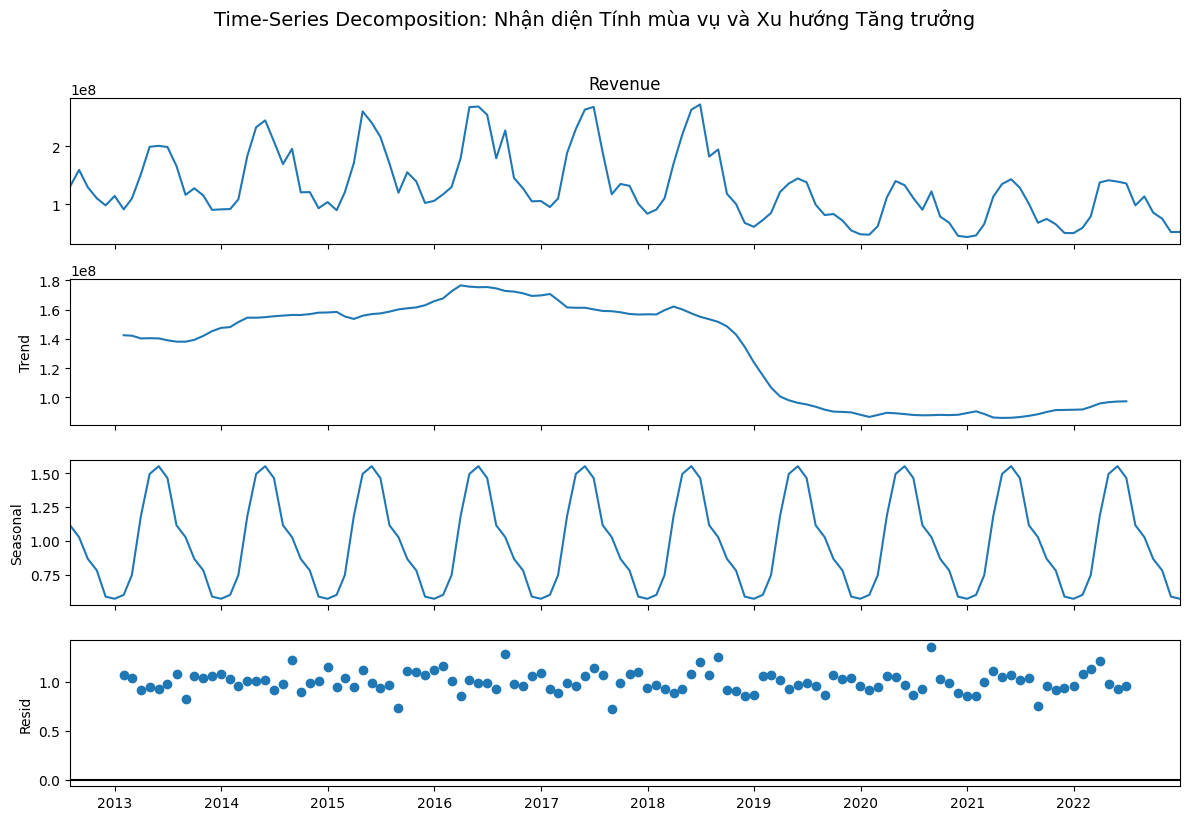

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Phân rã chuỗi thời gian (Descomposition) cho doanh thu hàng tháng
decompose_result = seasonal_decompose(monthly_sales['Revenue'], model='multiplicative', period=12)

fig = decompose_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Time-Series Decomposition: Nhận diện Tính mùa vụ và Xu hướng Tăng trưởng', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Đánh giá xu hướng

Biểu đồ doanh thu hàng tháng từ năm 2012 đến 2022 cho thấy một số xu hướng đáng chú ý:

*   **Xu hướng tăng trưởng tổng thể**: Nhìn chung, doanh thu có xu hướng tăng dần theo thời gian, đặc biệt là trong những năm đầu.
*   **Tính mùa vụ rõ rệt**: Có vẻ như có các đỉnh doanh thu lặp lại hàng năm, cho thấy tính mùa vụ trong hoạt động kinh doanh.
*   **Biến động hàng tháng**: Doanh thu có sự biến động đáng kể giữa các tháng, nhưng các mức cao nhất và thấp nhất có vẻ duy trì một khoảng nhất định.
*   **Sự suy giảm gần đây**: Có thể quan sát thấy một sự suy giảm hoặc chững lại trong tăng trưởng doanh thu ở những năm gần đây của giai đoạn (2019-2022), điều này có thể liên quan đến các yếu tố kinh tế vĩ mô hoặc cạnh tranh thị trường.

Further analyze the seasonal patterns to identify specific months or quarters with consistently high or low revenue, which could inform inventory management, marketing campaigns, and staffing decisions.

#### Calculate Average Monthly Revenue


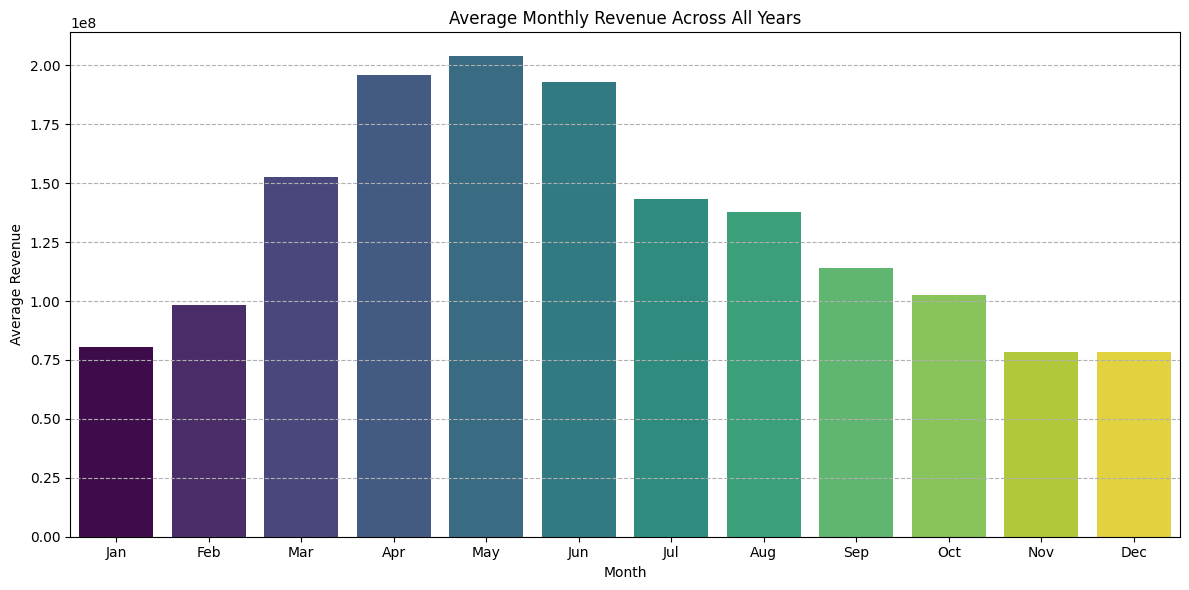

In [15]:
monthly_revenue = monthly_sales['Revenue']
avg_monthly_revenue = monthly_revenue.groupby(monthly_revenue.index.month).mean()
plt.figure(figsize=(12, 6))
sns.barplot(x=avg_monthly_revenue.index, y=avg_monthly_revenue.values, palette='viridis', hue=avg_monthly_revenue.index, legend=False)
plt.title('Average Monthly Revenue Across All Years')
plt.xlabel('Month')
plt.ylabel('Average Revenue')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

#### Calculate Average Quarterly Revenue

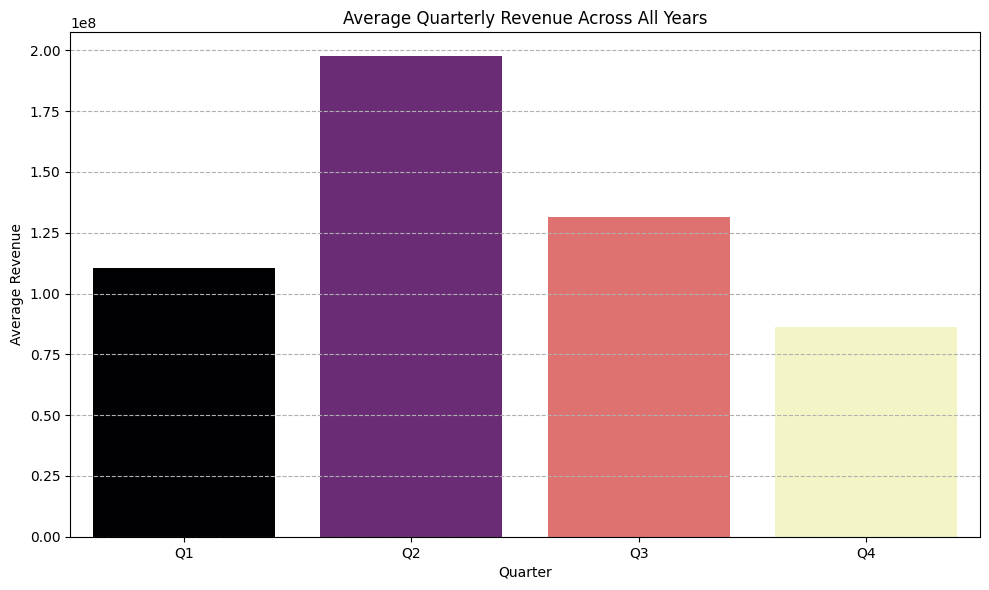

In [16]:
avg_quarterly_revenue = monthly_revenue.groupby(monthly_revenue.index.quarter).mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_quarterly_revenue.index, y=avg_quarterly_revenue.values, palette='magma', hue=avg_quarterly_revenue.index, legend=False)
plt.title('Average Quarterly Revenue Across All Years')
plt.xlabel('Quarter')
plt.ylabel('Average Revenue')
plt.xticks(ticks=range(0, 4), labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

####  Data Analysis Key Findings

*   **Average Monthly Revenue**: The average monthly revenue exhibits a clear seasonal pattern, with the highest revenues observed during Q2 (April, May, June) and a strong performance continuing into Q3 (July, August, September). December and January tend to have the lowest average revenues.
*   **Average Quarterly Revenue**: Q2 is consistently the strongest period for revenue, followed by Q3. Revenue generally declines in Q4 and remains lower in Q1.

#### Insights or Next Steps

*   **Strategic Resource Allocation**: Businesses should allocate higher marketing budgets and resources to Q2 and Q3 to capitalize on peak demand, while optimizing inventory and staffing for lower demand periods in Q4 and Q1.
*   **Targeted Business Operations**: Consider timing major product launches for Q2 to maximize initial sales and implement targeted promotions during slower months (Q4, Q1) to stimulate demand or clear old stock.


Next: Investigate the factors contributing to the observed revenue slowdown in 2019-2022, which could include macroeconomic changes, increased competition, or shifts in customer behavior.

### Tác động của Khuyến mãi và Vận hành
Khuyến mãi tác động như thế nào đến Doanh thu? Liệu các đợt bùng nổ doanh số có mang tính bền vững hay chỉ đang lợi dụng các đợt xả hàng?

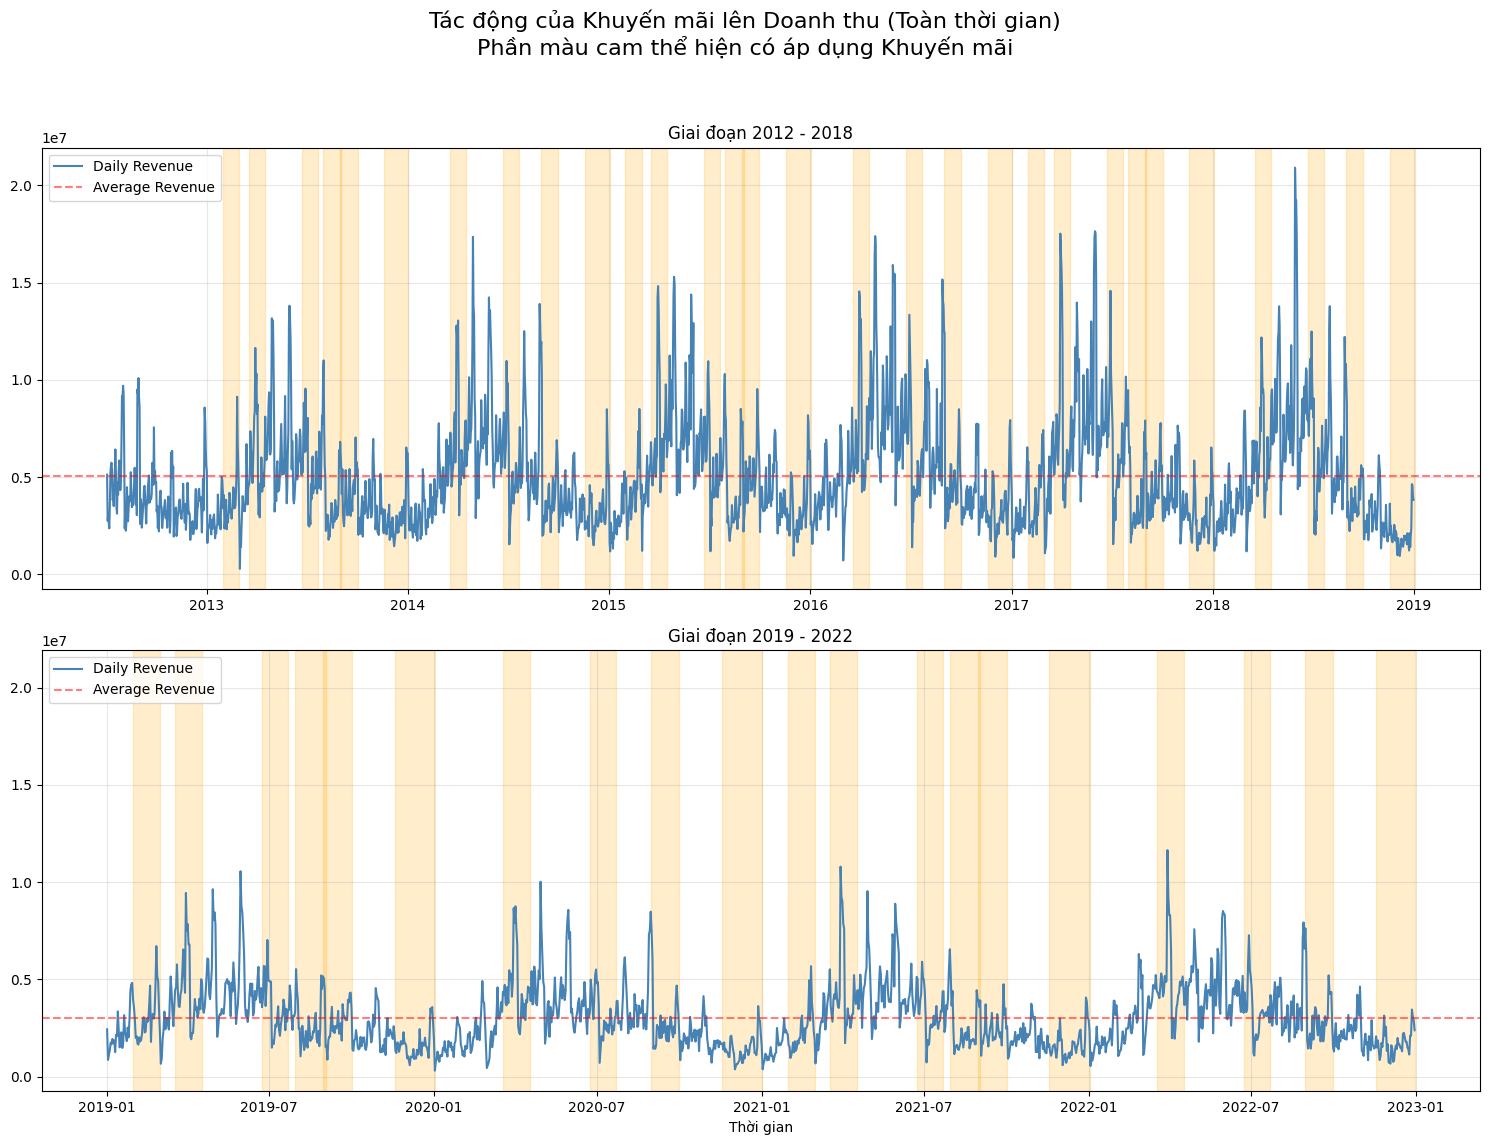

In [17]:
import matplotlib.dates as mdates

# Chia dữ liệu thành 2 giai đoạn: 2012-2018 và 2019-2022
sales_p1 = sales_ts[(sales_ts.index >= '2012-07-04') & (sales_ts.index < '2019-01-01')]
sales_p2 = sales_ts[sales_ts.index >= '2019-01-01']

promos_p1 = promotions[(promotions['start_date'] >= '2012-07-04') & (promotions['start_date'] < '2019-01-01')]
promos_p2 = promotions[promotions['start_date'] >= '2019-01-01']

# Khởi tạo figure với 2 trục dọc (subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharey=True)

# Hàm vẽ chung để tránh lặp code
def plot_data(ax, sales_data, promo_data, title):
    ax.plot(sales_data.index, sales_data['Revenue'], color='steelblue', label='Daily Revenue')
    baseline = sales_data['Revenue'].mean()
    ax.axhline(baseline, color='red', linestyle='--', alpha=0.5, label='Average Revenue')
    
    for _, row in promo_data.iterrows():
        ax.axvspan(row['start_date'], row['end_date'], color='orange', alpha=0.2)
    
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)

# Vẽ phần 1 (Giai đoạn cũ)
plot_data(ax1, sales_p1, promos_p1, 'Giai đoạn 2012 - 2018')

# Vẽ phần 2 (Giai đoạn mới)
plot_data(ax2, sales_p2, promos_p2, 'Giai đoạn 2019 - 2022')

plt.xlabel('Thời gian')
fig.suptitle('Tác động của Khuyến mãi lên Doanh thu (Toàn thời gian)\n''Phần màu cam thể hiện có áp dụng Khuyến mãi', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Tránh tiêu đề bị đè
plt.show()

#### Đánh giá
1. Phụ thuộc nặng nề vào Khuyến mãi
* Hầu hết các đỉnh doanh thu bùng nổ đều nằm gọn trong dải màu cam.
* Ngày không có sale, doanh thu thường lặn ngụp dưới đường trung bình đỏ. Khách hàng có tâm lý "chờ sale mới mua".

2. Hiệu ứng "Hụt doanh thu" sau sale (Post-promo dip)
* Ngay sau khi dải màu cam kết thúc, đường doanh thu thường rớt xuống mức đáy (thấp hơn cả ngày thường).
* Điều này cho thấy sale chủ yếu kích thích khách cũ "mua gom, tích trữ" chứ không tạo ra nhu cầu mua sắm bền vững.